In [380]:
from google.colab import drive
drive.mount('/content/drvie')

Drive already mounted at /content/drvie; to attempt to forcibly remount, call drive.mount("/content/drvie", force_remount=True).


In [381]:
import pandas as pd

file_path = '/content/drvie/MyDrive/inetrn/Devixo_Task_03_Superstore_Sales_12000.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded successfully with {len(df)} rows and {len(df.columns)} columns.")
print(df.head())

Dataset loaded successfully with 12015 rows and 19 columns.
     Order ID  Order Date   Ship Date Customer ID  Customer Name      Segment  \
0  ORD-006135  2024-11-15  2024-11-16  CUST-01032  Customer 1540    Corporate   
1  ORD-004672  2025-07-18  2025-07-20  CUST-00047  Customer 1186     Consumer   
2  ORD-005722  2024-05-18  2024-05-20  CUST-00578  Customer 1562  Home Office   
3  ORD-007221  2024-08-01  2024-08-05  CUST-00618  Customer 0205     Consumer   
4  ORD-000430  2024-10-25  2024-10-28  CUST-00431  Customer 0486     Consumer   

    Region          State          City         Category Sub-Category  \
0  Central        Indiana  Indianapolis       Technology  Accessories   
1     West     California     San Diego  Office Supplies      Binders   
2     East  Massachusetts     Worcester        Furniture      Storage   
3     West       Colorado        Denver       Technology      Laptops   
4  Central        Indiana  Indianapolis        Furniture    Bookcases   

      Product 

In [382]:
print(df.head)

<bound method NDFrame.head of          Order ID  Order Date   Ship Date Customer ID  Customer Name  \
0      ORD-006135  2024-11-15  2024-11-16  CUST-01032  Customer 1540   
1      ORD-004672  2025-07-18  2025-07-20  CUST-00047  Customer 1186   
2      ORD-005722  2024-05-18  2024-05-20  CUST-00578  Customer 1562   
3      ORD-007221  2024-08-01  2024-08-05  CUST-00618  Customer 0205   
4      ORD-000430  2024-10-25  2024-10-28  CUST-00431  Customer 0486   
...           ...         ...         ...         ...            ...   
12010  ORD-011965  2024-09-02  2024-09-04  CUST-00615  Customer 0641   
12011  ORD-005192  2025-02-17  2025-02-20  CUST-01242  Customer 1288   
12012  ORD-005391  2025-04-29  2025-05-03  CUST-01456  Customer 0585   
12013  ORD-000861  2025-02-15  2025-02-18  CUST-00606  Customer 0324   
12014  ORD-007271  2024-08-16  2024-08-20  CUST-00250  Customer 0811   

           Segment   Region          State          City         Category  \
0        Corporate  Central 

In [383]:
print(df.shape)

(12015, 19)


# **Missing Values**

In [384]:
print(df.isnull().sum())

Order ID           0
Order Date         0
Ship Date          0
Customer ID        0
Customer Name     12
Segment            0
Region             0
State              0
City              12
Category           0
Sub-Category       0
Product Name       0
Unit Price         0
Quantity           0
Discount           0
Sales              0
Profit             0
Payment Mode      12
Order Priority     0
dtype: int64


In [385]:
# Missing values count
missing = df.isnull().sum()

# Sirf woh columns show karo jahan missing values hain
missing = missing[missing > 0]

print("Missing Values:")
print(missing)

Missing Values:
Customer Name    12
City             12
Payment Mode     12
dtype: int64


In [386]:
# Missing values percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

print("Missing Values Percentage:")
print(missing_percentage)

Missing Values Percentage:
Customer Name    0.099875
City             0.099875
Payment Mode     0.099875
dtype: float64


# **Columns**

In [387]:
print("\n columns:")
print(df.columns.tolist())


 columns:
['Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name', 'Segment', 'Region', 'State', 'City', 'Category', 'Sub-Category', 'Product Name', 'Unit Price', 'Quantity', 'Discount', 'Sales', 'Profit', 'Payment Mode', 'Order Priority']


In [388]:
# Fill missing values with the most frequent value (mode)

df["Customer Name"] = df["Customer Name"].fillna(df["Customer Name"].mode()[0])
df["State"] = df["State"].fillna(df["State"].mode()[0])
df["Payment Mode"] = df["Payment Mode"].fillna(df["Payment Mode"].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [389]:
print(df.isnull().sum())

Order ID           0
Order Date         0
Ship Date          0
Customer ID        0
Customer Name      0
Segment            0
Region             0
State              0
City              12
Category           0
Sub-Category       0
Product Name       0
Unit Price         0
Quantity           0
Discount           0
Sales              0
Profit             0
Payment Mode       0
Order Priority     0
dtype: int64


# **Duplicate values**

In [390]:
# Check duplicate records

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 15


In [391]:
print(df.dtypes)

Order ID           object
Order Date         object
Ship Date          object
Customer ID        object
Customer Name      object
Segment            object
Region             object
State              object
City               object
Category           object
Sub-Category       object
Product Name       object
Unit Price        float64
Quantity            int64
Discount          float64
Sales             float64
Profit            float64
Payment Mode       object
Order Priority     object
dtype: object


In [392]:
# Convert Order_Date from object to datetime

df["Order Date"] = pd.to_datetime(df["Order Date"])

# Check the result
print(df["Order Date"].dtype)

datetime64[ns]


# **DataTypes**

In [393]:
print(df.dtypes)

Order ID                  object
Order Date        datetime64[ns]
Ship Date                 object
Customer ID               object
Customer Name             object
Segment                   object
Region                    object
State                     object
City                      object
Category                  object
Sub-Category              object
Product Name              object
Unit Price               float64
Quantity                   int64
Discount                 float64
Sales                    float64
Profit                   float64
Payment Mode              object
Order Priority            object
dtype: object


In [394]:
print("\n missing values:")
print(df.isnull().sum())
print("\n duplicate rows:")
print(df.duplicated().sum())


 missing values:
Order ID           0
Order Date         0
Ship Date          0
Customer ID        0
Customer Name      0
Segment            0
Region             0
State              0
City              12
Category           0
Sub-Category       0
Product Name       0
Unit Price         0
Quantity           0
Discount           0
Sales              0
Profit             0
Payment Mode       0
Order Priority     0
dtype: int64

 duplicate rows:
15


# **Feature Engineering**

In [395]:
# Feature Engineering from Order_Date

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Day"] = df["Order Date"].dt.day
df["Day_of_Week"] = df["Order Date"].dt.dayofweek

# Display the new features
print(df[["Order Date", "Year", "Month", "Day", "Day_of_Week"]].head())

  Order Date  Year  Month  Day  Day_of_Week
0 2024-11-15  2024     11   15            4
1 2025-07-18  2025      7   18            4
2 2024-05-18  2024      5   18            5
3 2024-08-01  2024      8    1            3
4 2024-10-25  2024     10   25            4


In [396]:
# Calculate Discount Amount

df["Discount_Amount"] = df["Sales"] * df["Discount"]

# Check the result
print(df[["Sales", "Discount", "Discount_Amount"]].head())

     Sales  Discount  Discount_Amount
0   278.26      0.40         111.3040
1    42.45      0.05           2.1225
2  1516.83      0.25         379.2075
3  5769.46      0.10         576.9460
4  1098.06      0.00           0.0000


In [397]:
# Calculate Profit Margin

df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

# Check the result
print(df[["Sales", "Profit", "Profit_Margin"]].head())

     Sales  Profit  Profit_Margin
0   278.26  -18.51      -6.652052
1    42.45    9.35      22.025913
2  1516.83  -24.83      -1.636967
3  5769.46  694.24      12.033015
4  1098.06  221.50      20.171940


In [398]:
# Make sure dates are datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Create Shipping Days
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print(df[["Order Date", "Ship Date", "Shipping Days"]].head())

  Order Date  Ship Date  Shipping Days
0 2024-11-15 2024-11-16              1
1 2025-07-18 2025-07-20              2
2 2024-05-18 2024-05-20              2
3 2024-08-01 2024-08-05              4
4 2024-10-25 2024-10-28              3


In [399]:
# Create Shipping Category

df["Shipping_Category"] = pd.cut(
    df["Shipping Days"],
    bins=[-1, 2, 5, float("inf")],
    labels=["Fast", "Standard", "Slow"]
)

# Check the result
print(df[["Shipping Days", "Shipping_Category"]].head())

   Shipping Days Shipping_Category
0              1              Fast
1              2              Fast
2              2              Fast
3              4          Standard
4              3          Standard


In [400]:
# Check updated dataset

print("Dataset Shape:", df.shape)

print("\nNew Features:")
print(df[[
    "Year",
    "Month",
    "Day",
    "Day_of_Week",
    "Discount_Amount",
    "Profit_Margin",
    "Shipping_Category"
]].head())

Dataset Shape: (12015, 27)

New Features:
   Year  Month  Day  Day_of_Week  Discount_Amount  Profit_Margin  \
0  2024     11   15            4         111.3040      -6.652052   
1  2025      7   18            4           2.1225      22.025913   
2  2024      5   18            5         379.2075      -1.636967   
3  2024      8    1            3         576.9460      12.033015   
4  2024     10   25            4           0.0000      20.171940   

  Shipping_Category  
0              Fast  
1              Fast  
2              Fast  
3          Standard  
4          Standard  


In [401]:
# Save the feature-engineered dataset
import os

output_path = "/content/drive/MyDrive/data science/sales_feature_engineered.csv"

# Create the directory if it does not exist
os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)

print("Dataset saved successfully!")
print(output_path)

Dataset saved successfully!
/content/drive/MyDrive/data science/sales_feature_engineered.csv


In [402]:
# Verify saved dataset

df_check = pd.read_csv(output_path)

print("Shape:", df_check.shape)
print("\nColumns:")
print(df_check.columns.tolist())

Shape: (12015, 27)

Columns:
['Order ID', 'Order Date', 'Ship Date', 'Customer ID', 'Customer Name', 'Segment', 'Region', 'State', 'City', 'Category', 'Sub-Category', 'Product Name', 'Unit Price', 'Quantity', 'Discount', 'Sales', 'Profit', 'Payment Mode', 'Order Priority', 'Year', 'Month', 'Day', 'Day_of_Week', 'Discount_Amount', 'Profit_Margin', 'Shipping Days', 'Shipping_Category']


# **Statistical Summary**

In [403]:
# Basic statistical summary

print(df.describe())

                          Order Date                      Ship Date  \
count                          12015                          12015   
mean   2024-12-31 19:43:45.617977600  2025-01-03 16:56:55.730336768   
min              2024-01-01 00:00:00            2024-01-02 00:00:00   
25%              2024-06-30 12:00:00            2024-07-04 00:00:00   
50%              2025-01-03 00:00:00            2025-01-05 00:00:00   
75%              2025-07-06 00:00:00            2025-07-09 00:00:00   
max              2025-12-31 00:00:00            2026-01-05 00:00:00   
std                              NaN                            NaN   

         Unit Price      Quantity      Discount         Sales        Profit  \
count  12015.000000  12015.000000  12015.000000  12015.000000  12015.000000   
mean     339.501695      3.696047      0.133550   1129.837427    140.576731   
min        5.020000      1.000000      0.000000      3.100000   -577.940000   
25%       36.440000      2.000000      0.050

In [404]:
# Check unique values and frequencies of categorical columns

categorical_columns = [
    "Segment",
    "Region",
    "State",
    "City",
    "Category",
    "Sub-Category",
    "Payment Mode",
    "Shipping_Category"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Segment ---
Segment
Consumer       6298
Corporate      3601
Home Office    2116
Name: count, dtype: int64

--- Region ---
Region
Central    3288
East       3161
South      2848
West       2718
Name: count, dtype: int64

--- State ---
State
Texas             569
Michigan          566
Maryland          560
Wisconsin         553
Ohio              549
New York          540
Massachusetts     529
Illinois          526
Indiana           525
Pennsylvania      523
Virginia          514
Florida           495
New Jersey        495
Louisiana         482
Oregon            482
Tennessee         480
Georgia           474
Washington        473
North Carolina    468
Alabama           449
Nevada            444
California        443
Arizona           439
Colorado          437
Name: count, dtype: int64

--- City ---
City
Baltimore           297
Detroit             297
Boston              281
Cleveland           279
Milwaukee           277
Virginia Beach      274
Madison             274
Indianapolis  

In [405]:
# Sales and Profit by Category

category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum()

print(category_analysis)

                      Sales      Profit
Category                               
Furniture        3968132.49   324640.01
Office Supplies   425789.16    85381.61
Technology       9181075.04  1279007.80


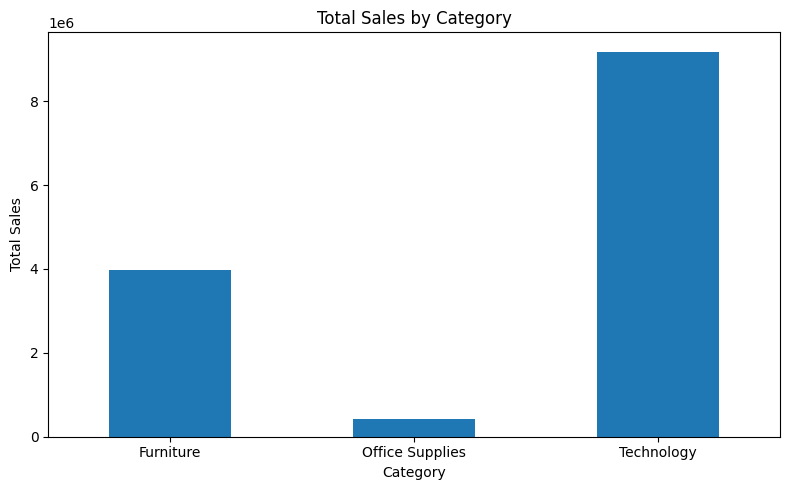

In [406]:
import matplotlib.pyplot as plt

# Category-wise Sales

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

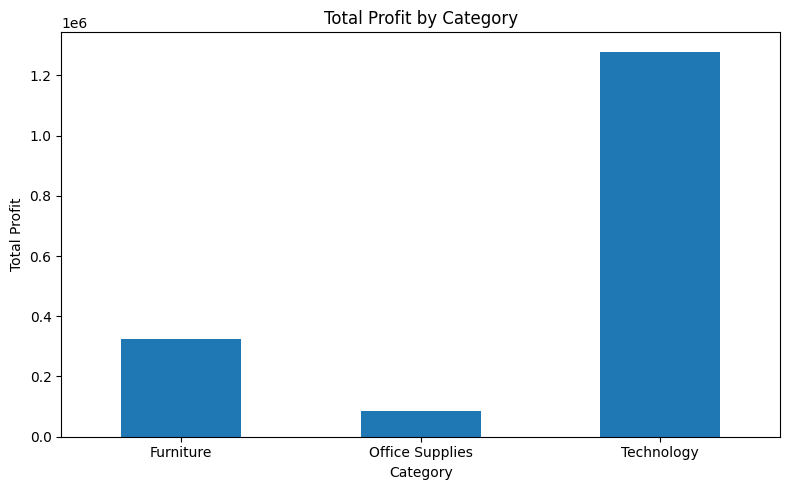

In [407]:
import matplotlib.pyplot as plt

# Category-wise Profit

category_profit = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(8, 5))
category_profit.plot(kind="bar")

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [408]:
# Monthly Sales Trend

monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

monthly_sales["Period"] = (
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str).str.zfill(2)
)

print(monthly_sales)

    Year  Month      Sales   Period
0   2024      1  629673.98  2024-01
1   2024      2  413590.88  2024-02
2   2024      3  528714.06  2024-03
3   2024      4  516200.96  2024-04
4   2024      5  548962.77  2024-05
5   2024      6  662184.23  2024-06
6   2024      7  590763.60  2024-07
7   2024      8  576167.47  2024-08
8   2024      9  558047.42  2024-09
9   2024     10  572004.68  2024-10
10  2024     11  616322.12  2024-11
11  2024     12  607156.75  2024-12
12  2025      1  541869.73  2025-01
13  2025      2  589400.15  2025-02
14  2025      3  555221.19  2025-03
15  2025      4  409983.20  2025-04
16  2025      5  581345.30  2025-05
17  2025      6  573833.67  2025-06
18  2025      7  597604.51  2025-07
19  2025      8  534500.47  2025-08
20  2025      9  576819.51  2025-09
21  2025     10  606012.81  2025-10
22  2025     11  534301.50  2025-11
23  2025     12  654315.73  2025-12


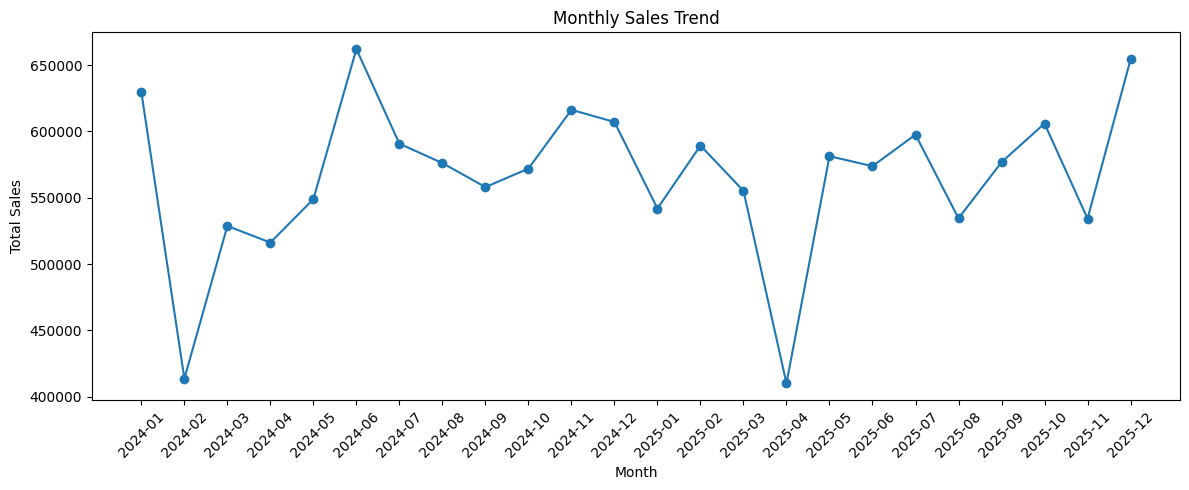

In [409]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Period"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

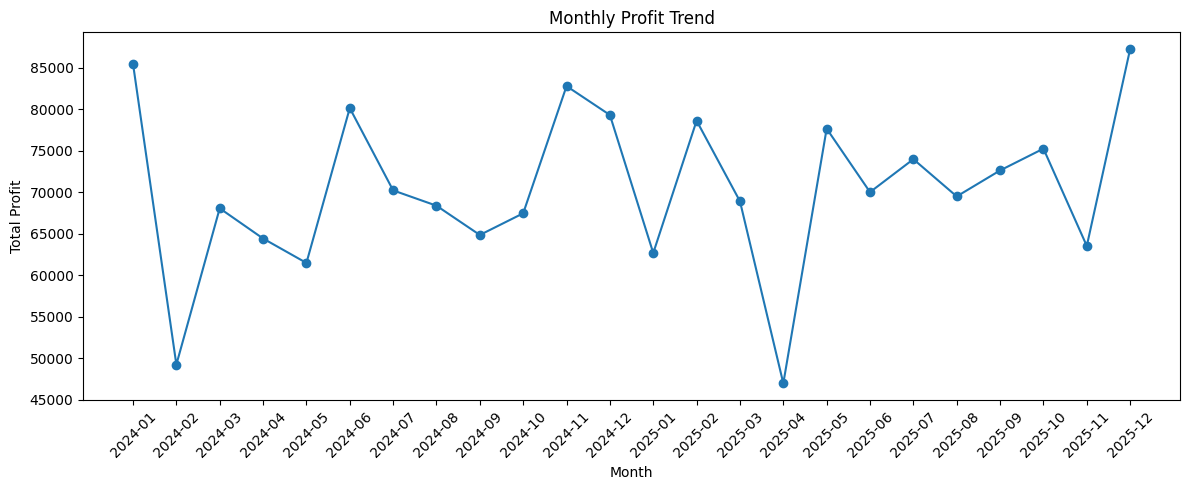

In [410]:
# Monthly Profit Trend

monthly_profit = df.groupby(["Year", "Month"])["Profit"].sum().reset_index()

monthly_profit["Period"] = (
    monthly_profit["Year"].astype(str) + "-" +
    monthly_profit["Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_profit["Period"],
    monthly_profit["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [411]:
# Region-wise Sales Analysis

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
Central    3700082.89
East       3493441.57
South      3306636.50
West       3074835.73
Name: Sales, dtype: float64


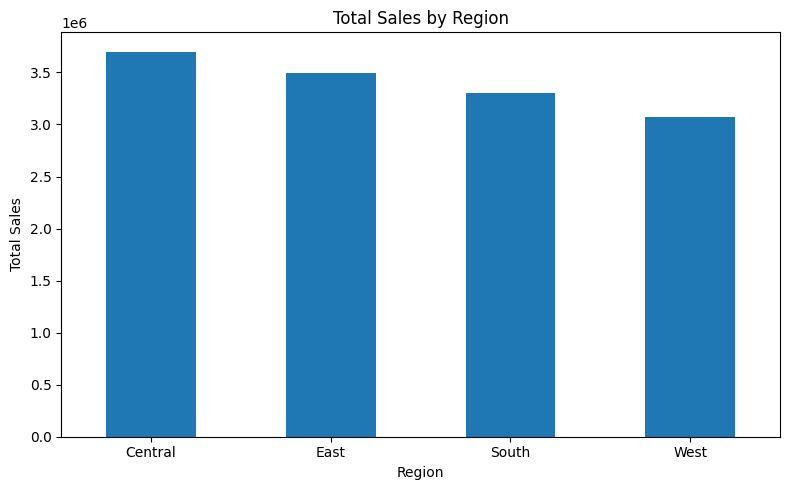

In [412]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [413]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Product Name
Lenovo ThinkPad     1135785.96
MacBook Air         1102042.49
Dell Inspiron       1055523.32
HP Pavilion         1012367.18
Pixel 8              880592.93
Galaxy S24           852193.62
OnePlus 12           764458.44
iPhone 15            721453.74
Conference Table     545089.27
Office Desk          483375.46
Name: Sales, dtype: float64


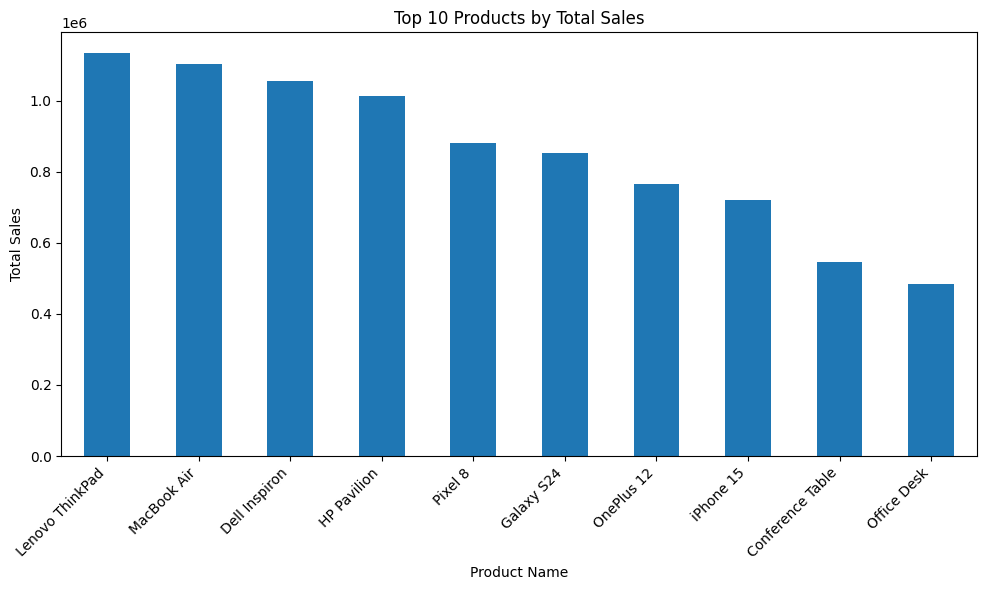

In [414]:
plt.figure(figsize=(10,6))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [415]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

Customer Name
Customer 0021    45396.33
Customer 0363    36021.97
Customer 0809    33148.60
Customer 0472    31163.20
Customer 0725    30702.90
Customer 0781    30475.25
Customer 1191    28832.84
Customer 0453    28773.32
Customer 1753    28127.26
Customer 0396    26947.42
Name: Sales, dtype: float64


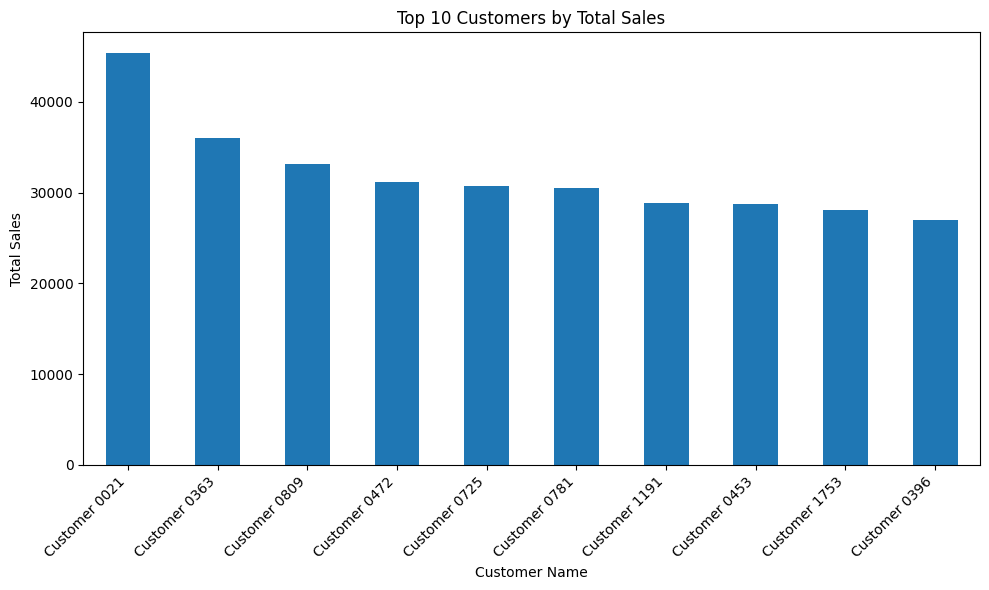

In [416]:
plt.figure(figsize=(10,6))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Customer Name")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [417]:
profit_analysis = df["Profit"].agg(
    ["sum", "mean", "min", "max"]
)

print("Profit Analysis:")
print(profit_analysis)

Profit Analysis:
sum     1.689029e+06
mean    1.405767e+02
min    -5.779400e+02
max     4.632580e+03
Name: Profit, dtype: float64


In [418]:
region_profit = (
    df.groupby("Region")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Region:")
print(region_profit)

Profit by Region:
Region
Central    469080.19
East       425728.67
South      407046.66
West       387173.90
Name: Profit, dtype: float64


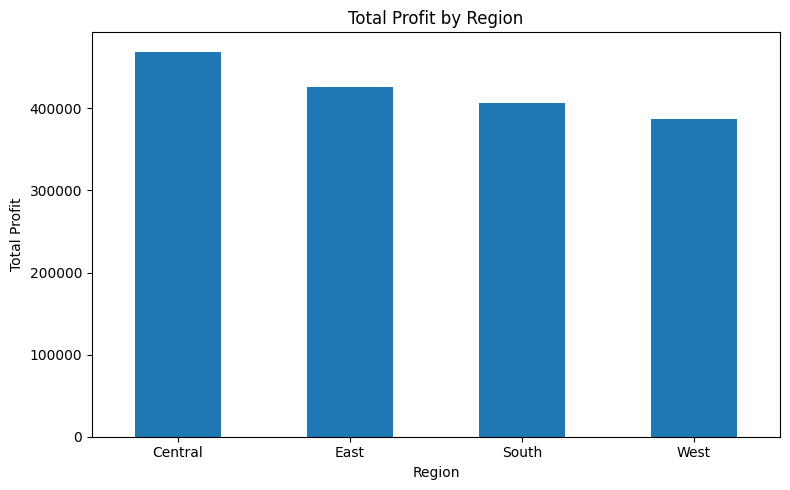

In [419]:
plt.figure(figsize=(8,5))
region_profit.plot(kind="bar")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [420]:
sales_trend = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

sales_trend["Period"] = (
    sales_trend["Year"].astype(str) + "-" +
    sales_trend["Month"].astype(str).str.zfill(2)
)

print(sales_trend)

    Year  Month      Sales   Period
0   2024      1  629673.98  2024-01
1   2024      2  413590.88  2024-02
2   2024      3  528714.06  2024-03
3   2024      4  516200.96  2024-04
4   2024      5  548962.77  2024-05
5   2024      6  662184.23  2024-06
6   2024      7  590763.60  2024-07
7   2024      8  576167.47  2024-08
8   2024      9  558047.42  2024-09
9   2024     10  572004.68  2024-10
10  2024     11  616322.12  2024-11
11  2024     12  607156.75  2024-12
12  2025      1  541869.73  2025-01
13  2025      2  589400.15  2025-02
14  2025      3  555221.19  2025-03
15  2025      4  409983.20  2025-04
16  2025      5  581345.30  2025-05
17  2025      6  573833.67  2025-06
18  2025      7  597604.51  2025-07
19  2025      8  534500.47  2025-08
20  2025      9  576819.51  2025-09
21  2025     10  606012.81  2025-10
22  2025     11  534301.50  2025-11
23  2025     12  654315.73  2025-12


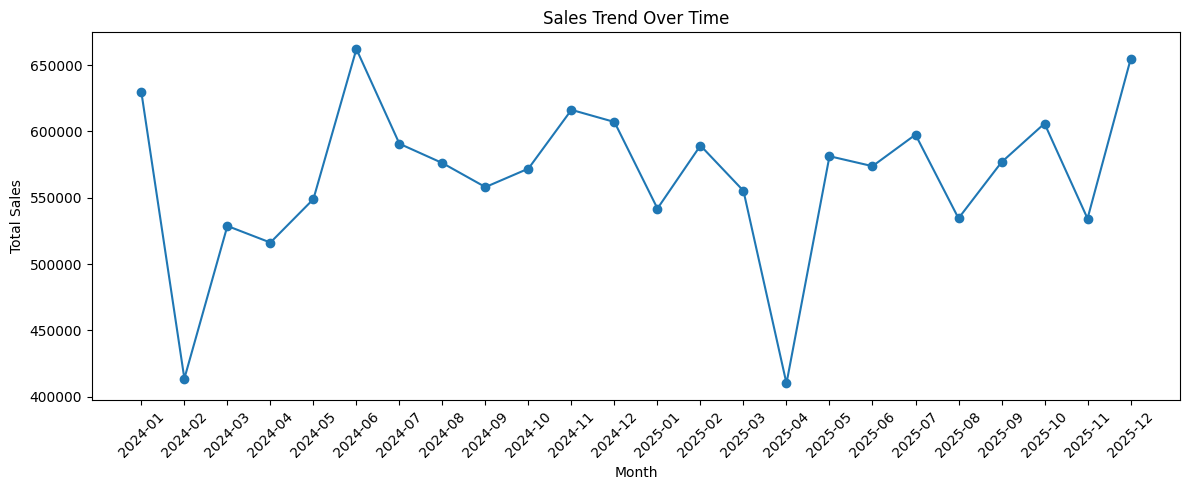

In [421]:
plt.figure(figsize=(12,5))
plt.plot(sales_trend["Period"], sales_trend["Sales"], marker="o")

plt.title("Sales Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [422]:
category_comparison = df.groupby("Category")[["Sales", "Profit"]].sum()

print("Category Comparison:")
print(category_comparison)

Category Comparison:
                      Sales      Profit
Category                               
Furniture        3968132.49   324640.01
Office Supplies   425789.16    85381.61
Technology       9181075.04  1279007.80


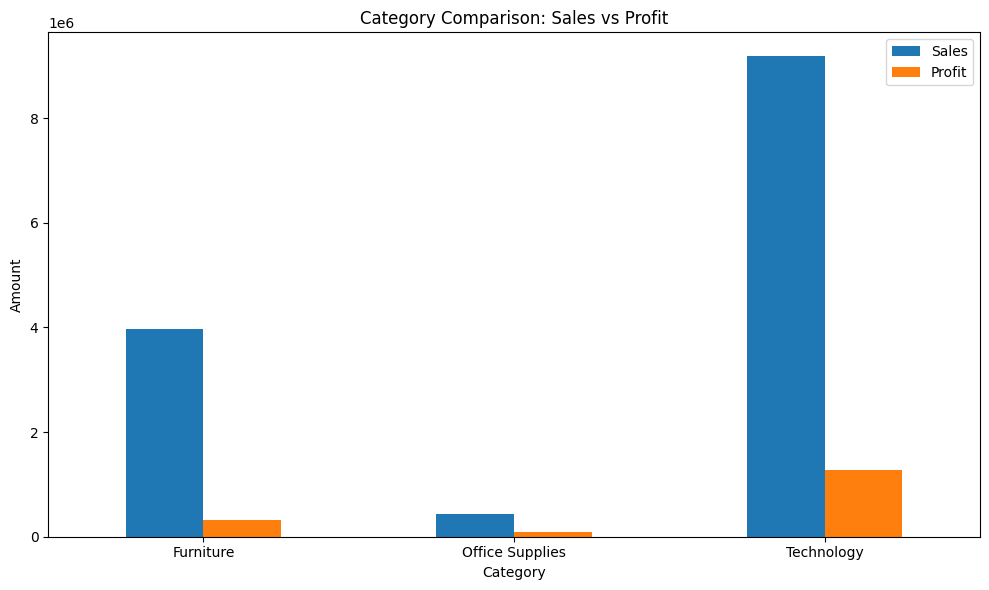

In [423]:
category_comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Category Comparison: Sales vs Profit")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [424]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
average_order_value = total_sales / total_orders

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Average Order Value:", average_order_value)

Total Sales: 13574996.690000001
Total Profit: 1689029.42
Total Orders: 12000
Average Order Value: 1131.2497241666667


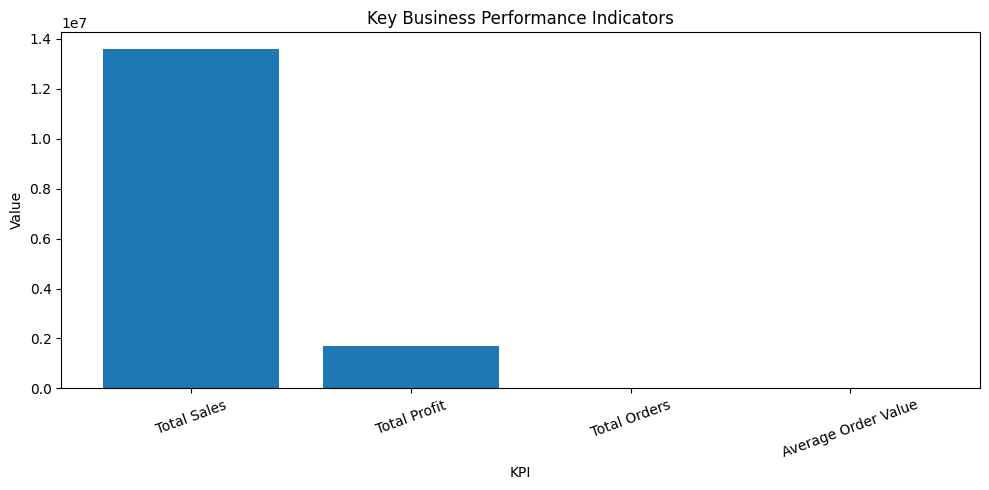

In [425]:
kpi_data = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Total Orders": total_orders,
    "Average Order Value": average_order_value
}

plt.figure(figsize=(10,5))
plt.bar(kpi_data.keys(), kpi_data.values())

plt.title("Key Business Performance Indicators")
plt.xlabel("KPI")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [426]:
top_profit_products = (
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Profit:")
print(top_profit_products)

Top 10 Products by Profit:
Product Name
Lenovo ThinkPad    158663.25
MacBook Air        157092.89
Dell Inspiron      148639.94
HP Pavilion        136196.00
Pixel 8            124721.51
Galaxy S24         116737.46
OnePlus 12         101263.26
iPhone 15          100544.64
Epson EcoTank       65194.46
HP LaserJet         62229.30
Name: Profit, dtype: float64


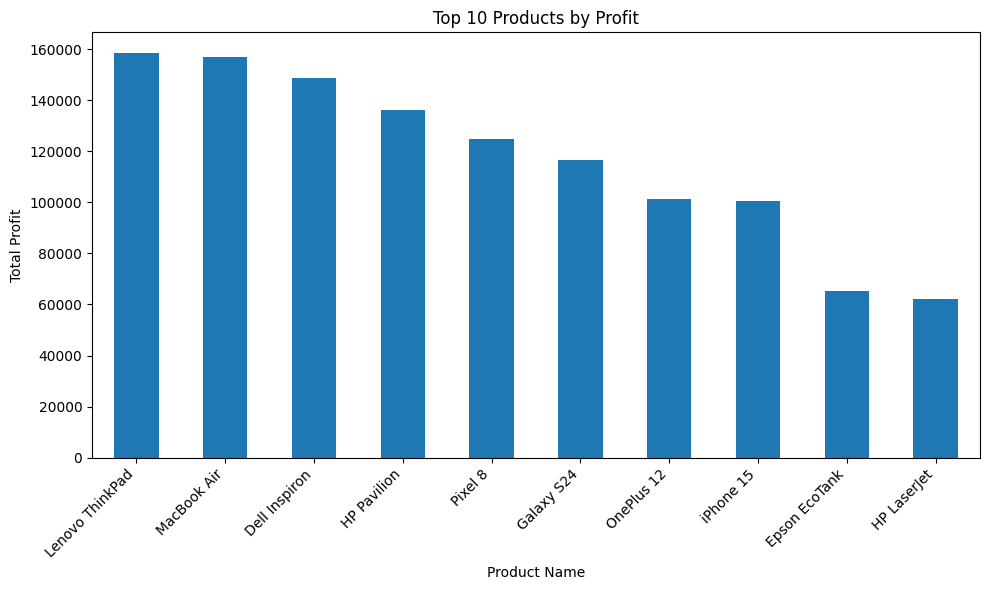

In [427]:
plt.figure(figsize=(10,6))
top_profit_products.plot(kind="bar")

plt.title("Top 10 Products by Profit")
plt.xlabel("Product Name")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [428]:
segment_analysis = df.groupby("Segment")[["Sales", "Profit"]].sum()

print("Customer Segment Analysis:")
print(segment_analysis)

Customer Segment Analysis:
                  Sales     Profit
Segment                           
Consumer     7168056.90  885924.93
Corporate    3989518.08  502971.97
Home Office  2417421.71  300132.52


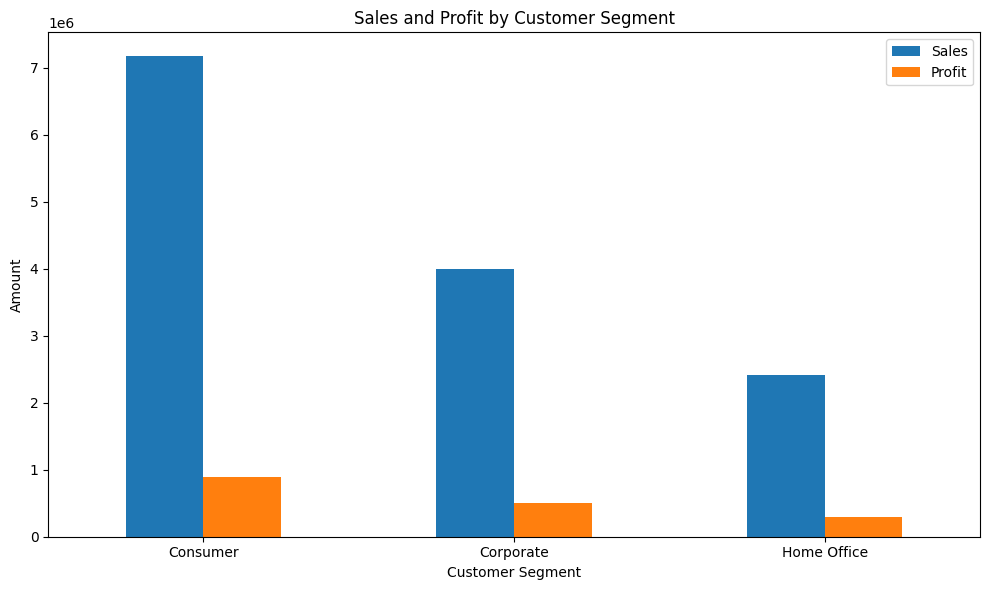

In [429]:
segment_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sales and Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [430]:
payment_analysis = df.groupby("Payment Mode")["Sales"].sum().sort_values(ascending=False)

print("Sales by Payment Method:")
print(payment_analysis)

Sales by Payment Method:
Payment Mode
Credit Card      5068685.37
Debit Card       2994472.73
PayPal           2594898.55
Bank Transfer    1787002.81
Cash             1129937.23
Name: Sales, dtype: float64


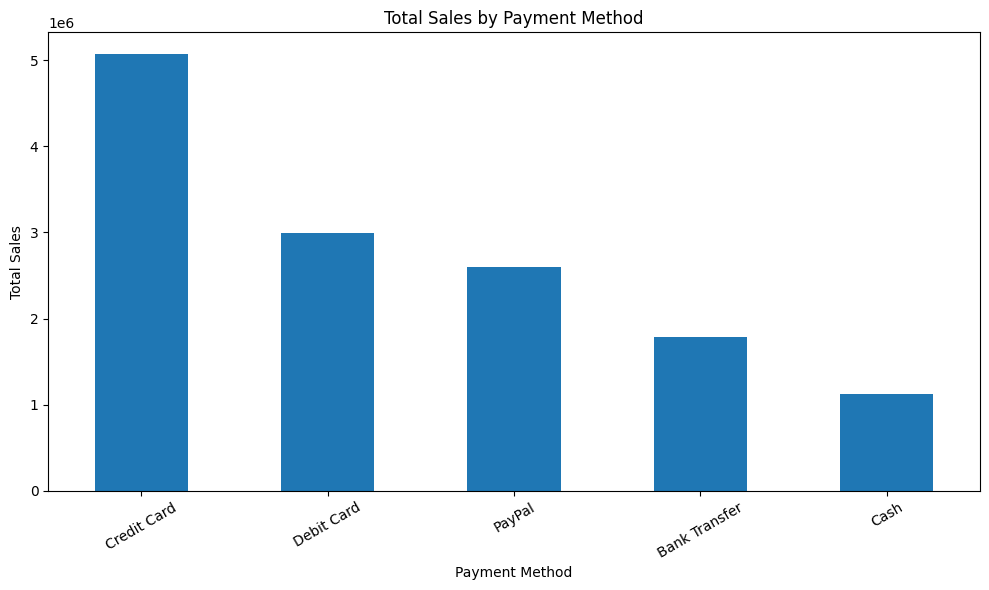

In [431]:
plt.figure(figsize=(10,6))
payment_analysis.plot(kind="bar")

plt.title("Total Sales by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [432]:
shipping_analysis = df.groupby("Shipping_Category")[["Sales", "Profit"]].sum()

print("Shipping Performance:")
print(shipping_analysis)

Shipping Performance:
                        Sales     Profit
Shipping_Category                       
Fast               5391838.02  667811.99
Standard           7792629.86  967792.99
Slow                390528.81   53424.44


/tmp/ipykernel_5268/1330666190.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shipping_analysis = df.groupby("Shipping_Category")[["Sales", "Profit"]].sum()


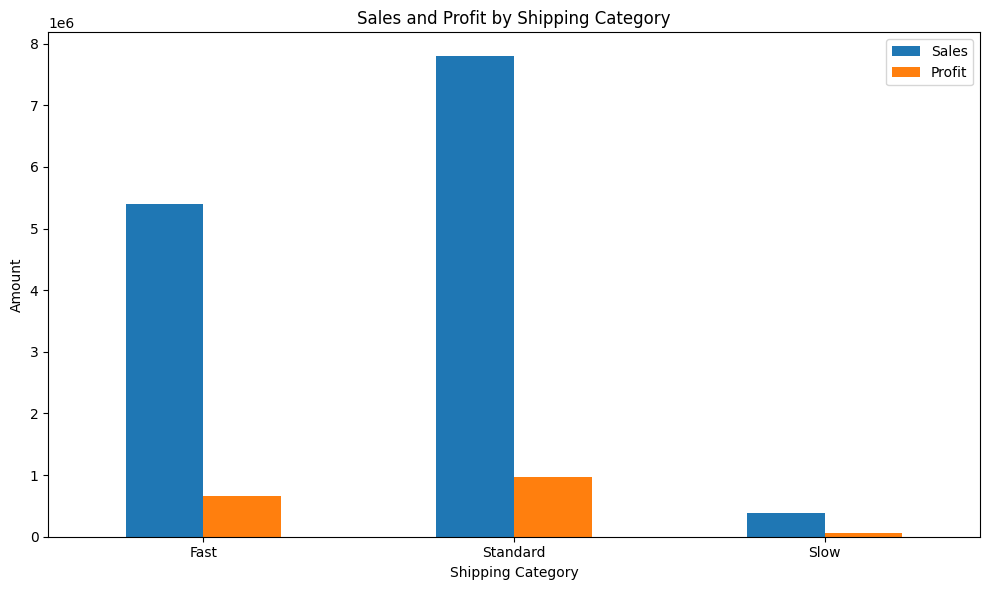

In [433]:
shipping_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sales and Profit by Shipping Category")
plt.xlabel("Shipping Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **Correlation**

In [434]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                 Unit Price  Quantity  Discount     Sales    Profit  \
Unit Price         1.000000  0.005779  0.007596  0.767297  0.621415   
Quantity           0.005779  1.000000  0.003265  0.405584  0.299563   
Discount           0.007596  0.003265  1.000000 -0.065983 -0.281032   
Sales              0.767297  0.405584 -0.065983  1.000000  0.857445   
Profit             0.621415  0.299563 -0.281032  0.857445  1.000000   
Discount_Amount    0.615769  0.328108  0.334817  0.703247  0.301820   
Profit_Margin     -0.182924 -0.008167 -0.739359 -0.088369  0.196689   
Shipping Days     -0.001055  0.001384 -0.002465  0.006125  0.010194   

                 Discount_Amount  Profit_Margin  Shipping Days  
Unit Price              0.615769      -0.182924      -0.001055  
Quantity                0.328108      -0.008167       0.001384  
Discount                0.334817      -0.739359      -0.002465  
Sales                   0.703247      -0.088369       0.006125  
Profit         

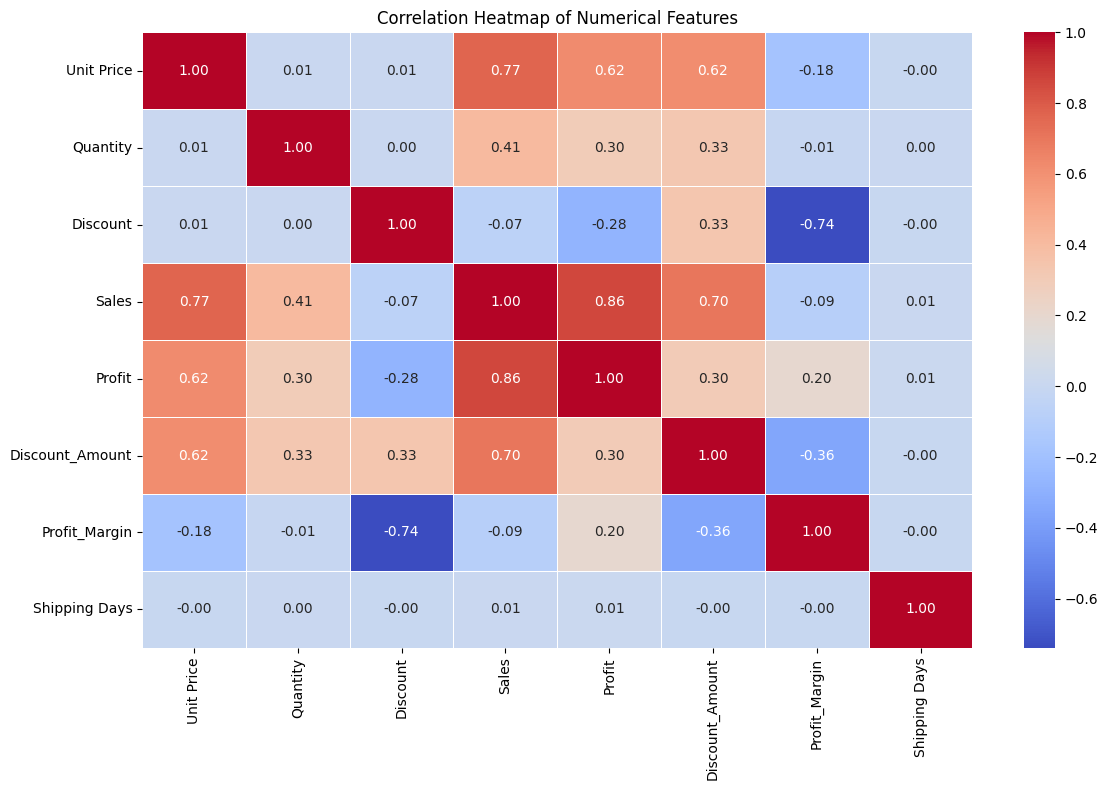

In [435]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

In [436]:
corr_pairs = correlation_matrix.unstack()

corr_pairs = corr_pairs[
    (corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1))
]

corr_pairs = corr_pairs.sort_values(ascending=False)

print("Strong Positive Relationships:")
print(corr_pairs.head(10))

print("\nStrong Negative Relationships:")
print(corr_pairs.tail(10))

Strong Positive Relationships:
Profit           Sales              0.857445
Sales            Profit             0.857445
Unit Price       Sales              0.767297
Sales            Unit Price         0.767297
Discount_Amount  Sales              0.703247
Sales            Discount_Amount    0.703247
Unit Price       Profit             0.621415
Profit           Unit Price         0.621415
Discount_Amount  Unit Price         0.615769
Unit Price       Discount_Amount    0.615769
dtype: float64

Strong Negative Relationships:
Profit_Margin    Sales             -0.088369
Sales            Profit_Margin     -0.088369
Unit Price       Profit_Margin     -0.182924
Profit_Margin    Unit Price        -0.182924
Profit           Discount          -0.281032
Discount         Profit            -0.281032
Profit_Margin    Discount_Amount   -0.355462
Discount_Amount  Profit_Margin     -0.355462
Discount         Profit_Margin     -0.739359
Profit_Margin    Discount          -0.739359
dtype: float64


# **Outlier**

In [437]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

print("Outlier Count by Numerical Feature:")
print(pd.Series(outlier_summary).sort_values(ascending=False))

Outlier Count by Numerical Feature:
Profit             1503
Discount_Amount    1399
Sales              1119
Unit Price          798
Quantity            166
Profit_Margin        90
Discount              0
Shipping Days         0
dtype: int64


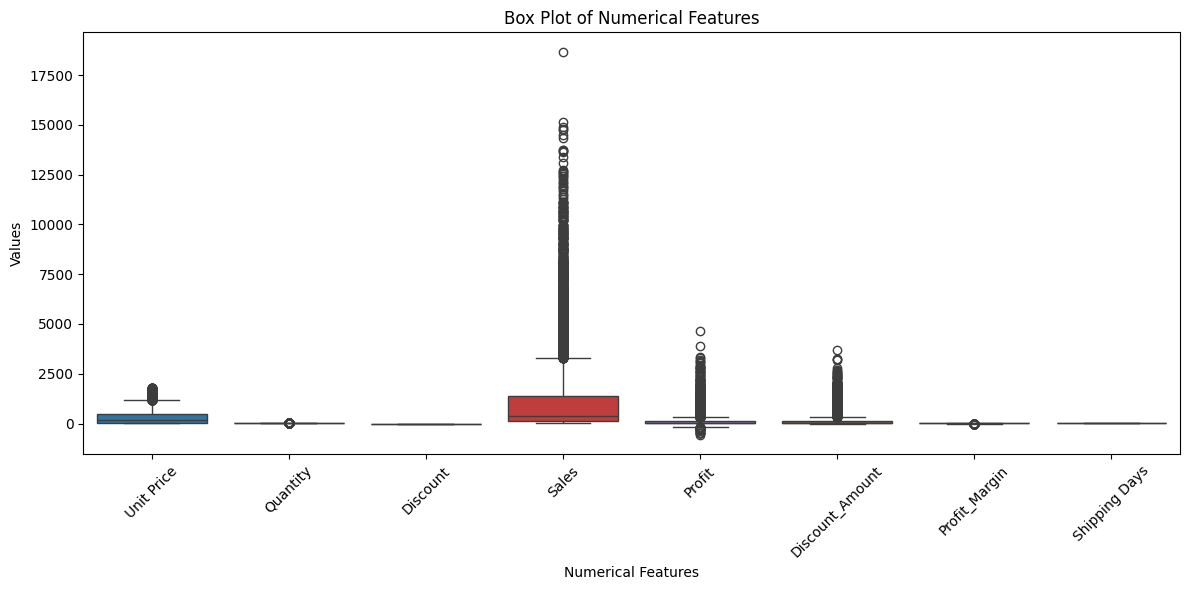

In [438]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[numeric_columns])

plt.title("Box Plot of Numerical Features")
plt.xlabel("Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

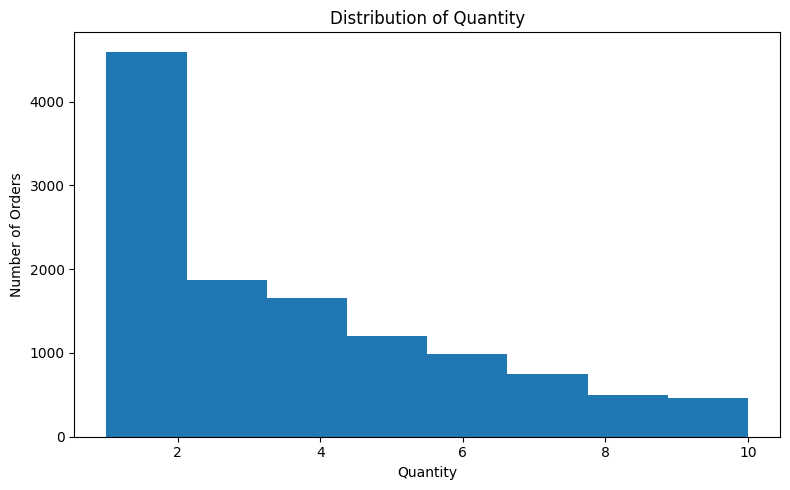

In [439]:
plt.figure(figsize=(8,5))

plt.hist(df["Quantity"], bins=8)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

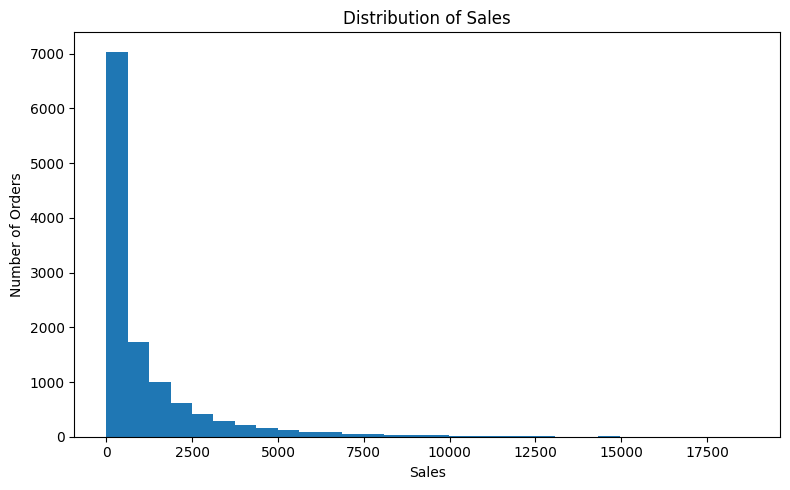

In [440]:
plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

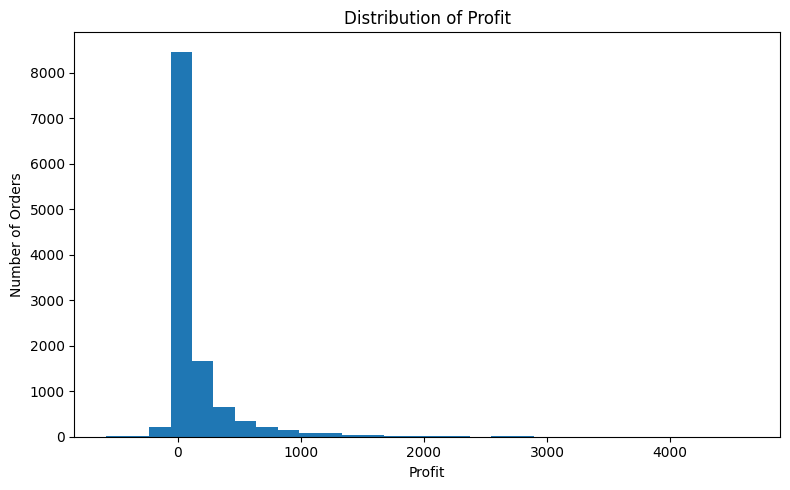

In [441]:
plt.figure(figsize=(8,5))

plt.hist(df["Profit"], bins=30)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

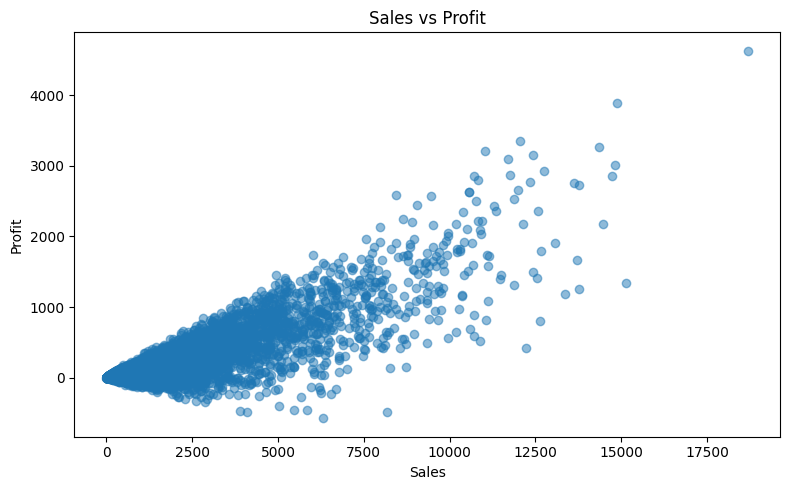

In [442]:
plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"], alpha=0.5)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

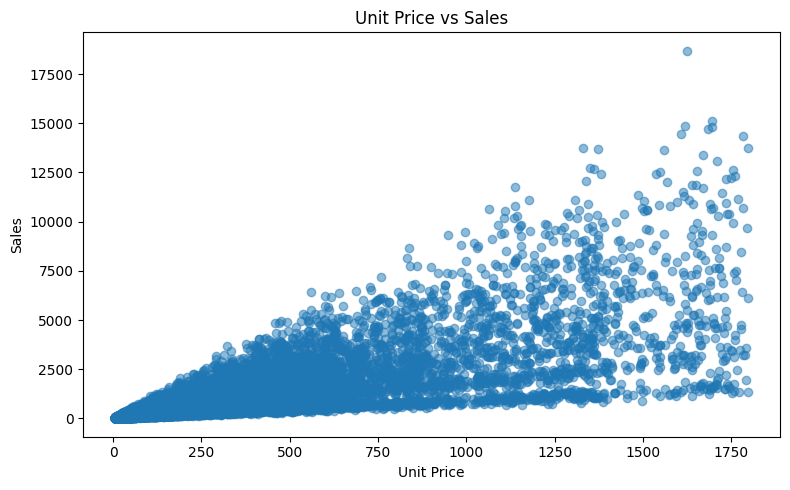

In [443]:
plt.figure(figsize=(8,5))

plt.scatter(df["Unit Price"], df["Sales"], alpha=0.5)

plt.title("Unit Price vs Sales")
plt.xlabel("Unit Price")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

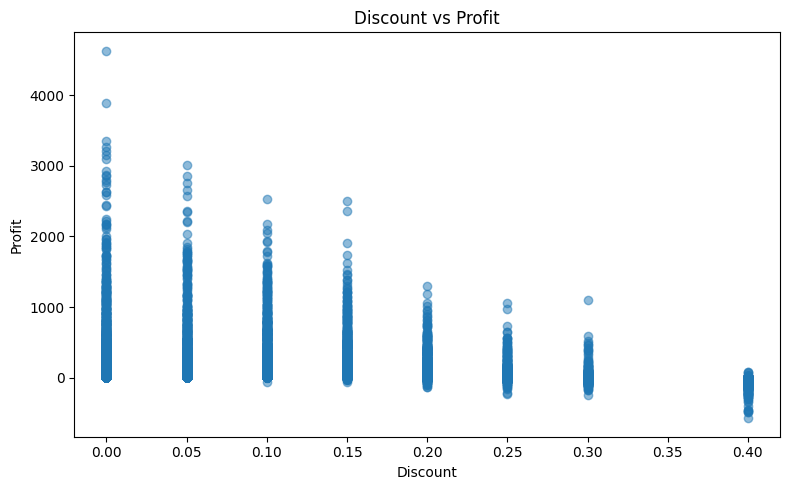

In [444]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"], alpha=0.5)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [445]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by State:")
print(state_sales)

Sales by State:
State
Texas             662113.67
Wisconsin         631601.64
Indiana           628307.59
North Carolina    622935.27
Ohio              619739.05
Maryland          607822.64
Michigan          606568.73
Virginia          603058.52
Oregon            598444.71
New Jersey        598379.51
Georgia           586711.32
Massachusetts     583145.85
New York          555405.57
Florida           551760.33
Illinois          551752.21
Tennessee         548045.38
Pennsylvania      545629.48
Washington        520821.67
Alabama           515781.47
Colorado          495807.98
Arizona           494200.30
Nevada            485665.51
Louisiana         481402.73
California        479895.56
Name: Sales, dtype: float64


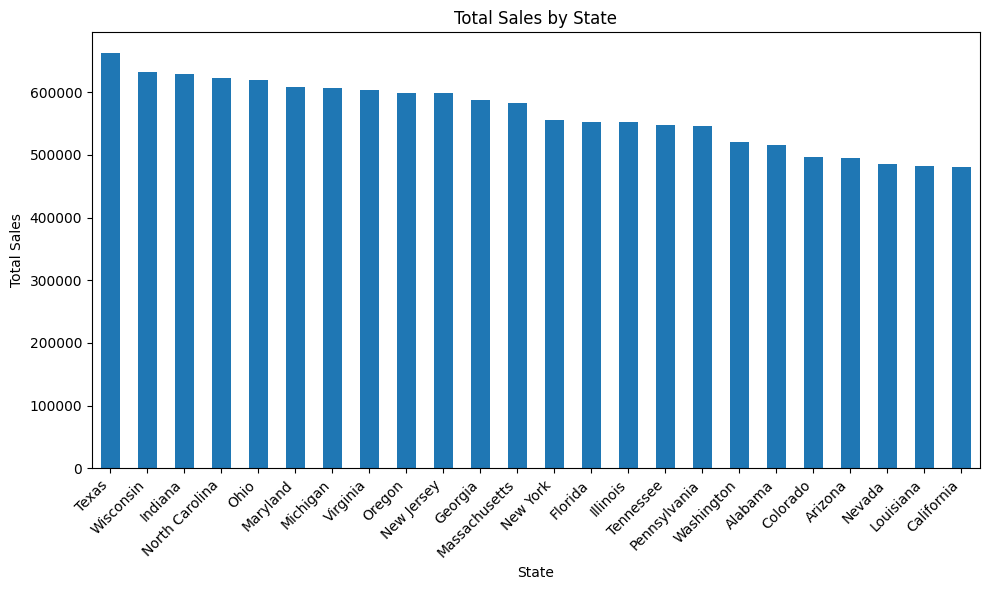

In [446]:
plt.figure(figsize=(10,6))

state_sales.plot(kind="bar")

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [447]:
city_sales = (
    df.groupby("City")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by City:")
print(city_sales)

Sales by City:
City
Indianapolis        339877.51
Savannah            333826.49
Madison             327333.74
Charlotte           326817.94
Baltimore           325106.52
Salem               323217.01
Detroit             320848.06
Newark              311094.90
Virginia Beach      310536.16
Cleveland           310445.43
Columbus            307961.76
Milwaukee           300547.14
Worcester           297001.07
Raleigh             295913.99
Chicago             293956.44
Richmond            292522.36
Fort Wayne          288343.20
Philadelphia        287844.77
Jersey City         287284.61
Boston              286144.78
Mobile              284673.77
Grand Rapids        282821.40
Frederick           282716.12
Nashville           277949.42
Portland            275227.70
Spokane             271730.00
Phoenix             271181.95
Memphis             270095.96
Las Vegas           266918.50
Springfield         257795.77
Pittsburgh          257784.71
Denver              253698.64
Atlanta             

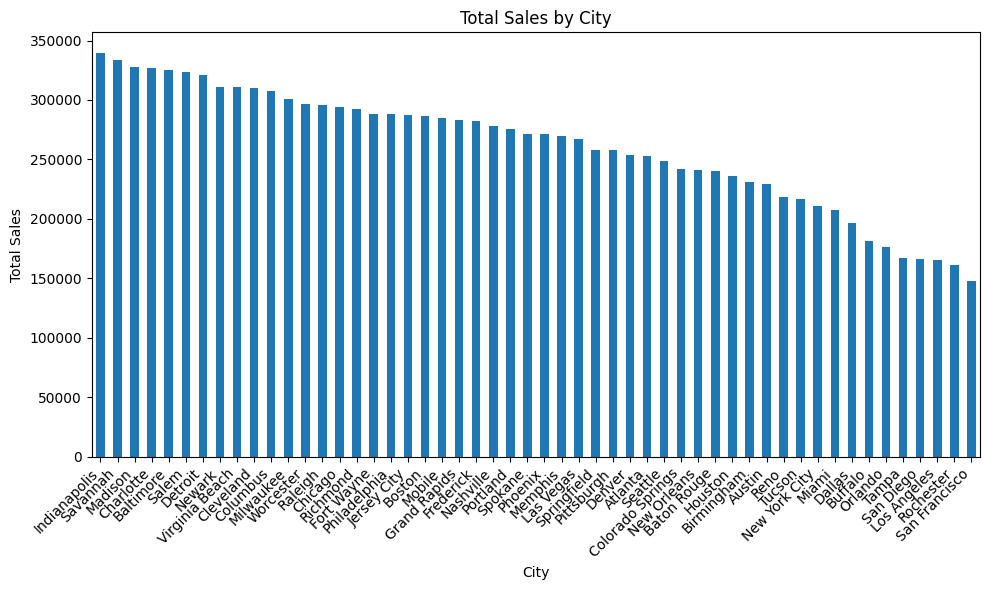

In [448]:
plt.figure(figsize=(10,6))

city_sales.plot(kind="bar")

plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [449]:
payment_counts = df["Payment Mode"].value_counts()

print("Payment Method Distribution:")
print(payment_counts)

Payment Method Distribution:
Payment Mode
Credit Card      4369
Debit Card       2584
PayPal           2405
Bank Transfer    1689
Cash              968
Name: count, dtype: int64


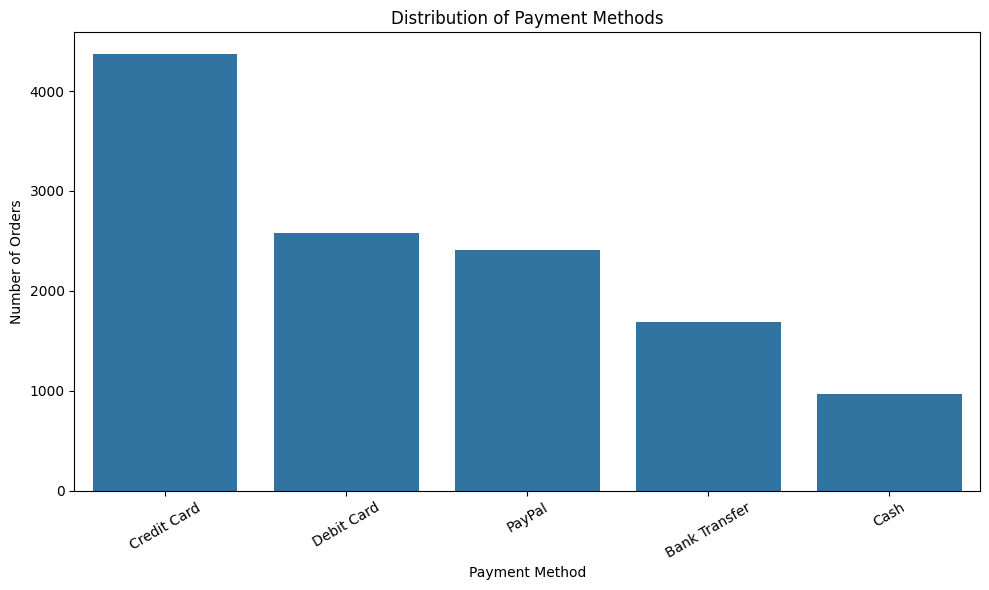

In [450]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Payment Mode",
    order=payment_counts.index
)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [451]:
category_counts = df["Category"].value_counts()

print("Category Distribution:")
print(category_counts)

Category Distribution:
Category
Technology         4228
Office Supplies    4188
Furniture          3599
Name: count, dtype: int64


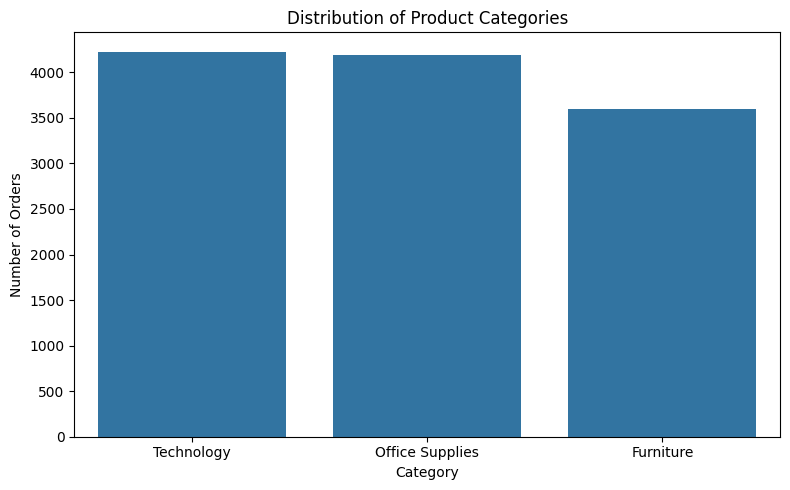

In [452]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Category",
    order=category_counts.index
)

plt.title("Distribution of Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [453]:
segment_counts = df["Segment"].value_counts()

print("Customer Segment Distribution:")
print(segment_counts)

Customer Segment Distribution:
Segment
Consumer       6298
Corporate      3601
Home Office    2116
Name: count, dtype: int64


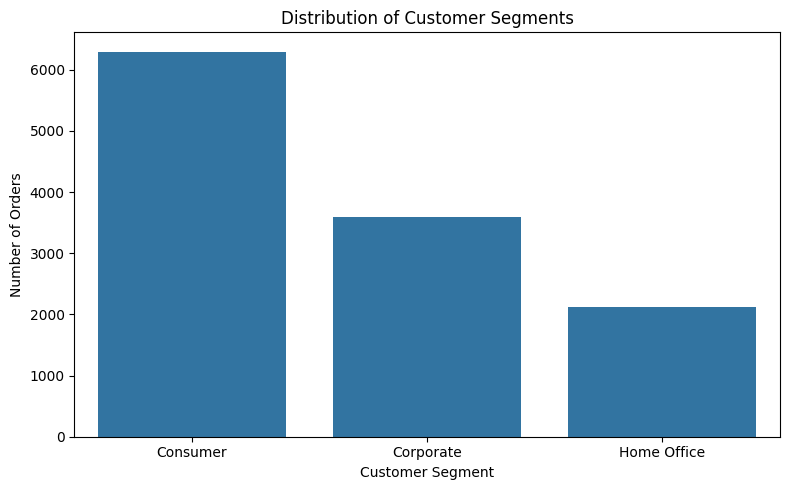

In [454]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Segment",
    order=segment_counts.index
)

plt.title("Distribution of Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [455]:
shipping_days_counts = df["Shipping Days"].value_counts().sort_index()

print("Shipping Days Distribution:")
print(shipping_days_counts)

Shipping Days Distribution:
Shipping Days
1    1170
2    3586
3    4227
4    1854
5     854
6     324
Name: count, dtype: int64


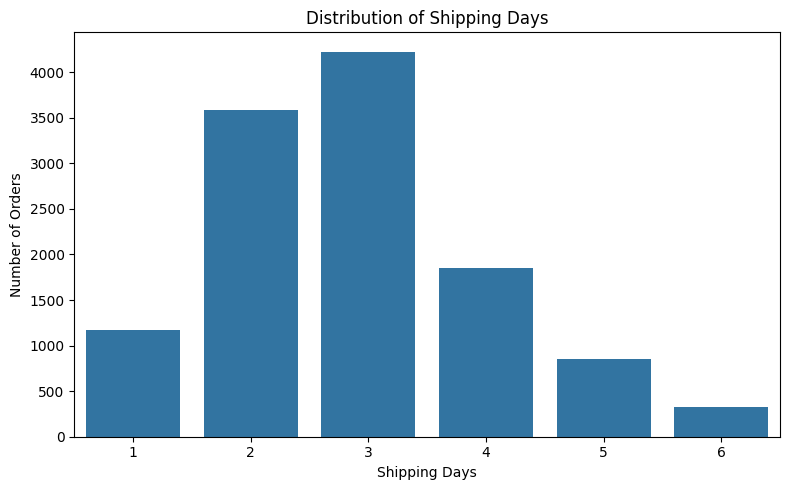

In [456]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Shipping Days",
    order=sorted(df["Shipping Days"].unique())
)

plt.title("Distribution of Shipping Days")
plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

# **Business Insights**

In [457]:
## Business Insights

1.  #**Technology Dominates Sales and Profit**: The 'Technology' category is by far the highest contributor to both total sales ($9.17M) and total profit ($1.28M), indicating it's the core revenue and profit driver. This suggests continued investment and focus on technology products.

2.  #**Furniture Category's Profitability Challenge**: While 'Furniture' has significant sales ($3.96M), its profit margin is considerably lower ($324K) compared to Technology. This indicates potential issues with pricing, costs, or discount strategies within the furniture segment that need to be addressed.

3.  #**Office Supplies - Moderate Performance**: 'Office Supplies' contributes the least to sales ($425K) but maintains a decent profit margin ($85K). This category might be suitable for cross-selling with higher-value items.

4. # **Monthly Sales Volatility**: The monthly sales trend shows fluctuations, with notable dips in certain months (e.g., February 2024, April 2025). Understanding the reasons behind these dips (e.g., seasonal, promotional, external factors) can help in better sales forecasting and planning targeted campaigns.

5.  #**Monthly Profit Fluctuations Mirror Sales**: Similar to sales, monthly profit also shows variations, which often align with sales trends. Analyzing periods of low profit can reveal specific challenges or costs incurred during those times.

6.  #**Regional Sales Distribution**: 'Central' and 'East' regions are the top performers in terms of total sales, followed closely by 'South' and 'West'. This balanced distribution across regions suggests a broad market presence, but also opportunities to boost sales in the 'West' region.

7.  #**Regional Profit Contribution**: All regions contribute positively to profit, with 'Central' leading, followed by 'East', 'South', and 'West'. This aligns with sales performance, suggesting consistent operational efficiency across regions.

8. # **Top Products Dominated by High-Tech and Office Furniture**: 'Lenovo ThinkPad', 'MacBook Air', 'Dell Inspiron', 'HP Pavilion', 'Pixel 8', 'Galaxy S24', 'OnePlus 12', and 'iPhone 15' are the top sales drivers. 'Conference Table' and 'Office Desk' are also strong performers, indicating a mix of consumer electronics and essential office furniture are key.

9. # **Consistent Top Profit Products**: The top products by profit largely mirror the top products by sales, particularly for the electronics. This reinforces their importance to the business's bottom line.

10. #**Key Customers Drive Significant Sales**: A small number of 'Customer' accounts (e.g., Customer 0021, Customer 0363) are responsible for a disproportionately large share of sales. Implementing loyalty programs or dedicated account management for these high-value customers could be beneficial.

11. #**Credit Card is Preferred Payment Method**: 'Credit Card' is the most popular payment method, accounting for the highest number of transactions and total sales. Ensuring seamless credit card processing and potentially offering incentives for its use could further enhance customer experience.

12. #**Standard Shipping is Most Common**: The 'Standard' shipping category accounts for the highest sales and profit, indicating it's the most utilized option. While 'Fast' shipping also performs well, 'Slow' shipping has significantly lower sales and profit, suggesting it might be less preferred or used for lower-value items.

13. #**Strong Positive Correlation between Sales, Profit, and Unit Price**: There is a strong positive correlation between 'Sales' and 'Profit' (0.86), and also between 'Unit Price' and 'Sales' (0.77). This suggests that higher-priced items generally lead to higher sales and, consequently, higher profits.

14. #**Negative Correlation between Discount and Profit Margin**: A strong negative correlation exists between 'Discount' and 'Profit_Margin' (-0.74). This highlights that aggressive discounting significantly erodes profit margins, emphasizing the need for strategic and controlled discount policies.

15. #**Outliers in Financial Metrics**: 'Profit', 'Sales', 'Discount_Amount', and 'Unit Price' show a considerable number of outliers, indicating high-value transactions or unusual profit/loss scenarios. Further investigation into these outliers could reveal exceptional deals, high-value customers, or areas of significant loss.

15.0

# **Executive Summary**

In [458]:
## Executive Summary: Superstore Sales Performance Analysis

#This analysis of Superstore Sales data, comprising 12,000 orders over two years (2024-2025), reveals a robust overall performance with **Total Sales of over $13.5 million** and **Total Profit exceeding $1.6 million**. The average order value stands at approximately $1,130.

#**Key Strengths & Opportunities:**
 # **Technology is the primary growth engine**, dominating both sales ($9.17M) and profit ($1.28M). High-tech products like 'Lenovo ThinkPad', 'MacBook Air', and 'Dell Inspiron' are consistent top performers, indicating a strong market for these items. Continued focus and investment in the Technology category are crucial.
 #**Strong Customer Base**: A small group of high-value customers contribute significantly to sales, highlighting the importance of customer retention and loyalty programs.
 #**Efficient Shipping**: The majority of orders utilize 'Standard' or 'Fast' shipping, with most deliveries completed within 2-3 days, suggesting generally efficient logistics.
 # **Credit Card Dominance**: 'Credit Card' is the most preferred payment method, simplifying transactions and potentially indicating customer preference for convenience and security.

#**Areas for Improvement & Strategic Considerations:**

#   **Furniture's Profitability Challenge**: Despite substantial sales ($3.96M), the 'Furniture' category exhibits a comparatively lower profit margin ($324K). This suggests potential issues with pricing, cost structures, or discount strategies within this segment that require immediate attention to improve profitability.
#  **Impact of Discounts on Profit**: A strong negative correlation between 'Discount' and 'Profit Margin' underscores that aggressive discounting significantly erodes profitability. A more strategic and controlled approach to promotions is advised to maintain healthy margins.
#  **Monthly Sales Volatility**: While overall trends are positive, monthly sales and profit show fluctuations, with notable dips in certain months (e.g., February 2024, April 2025). Investigating the causes of these dips (e.g., seasonal factors, competitive landscape) can help optimize future planning and mitigate risks.
#  **Outlier Management**: The presence of significant outliers in 'Profit', 'Sales', and 'Discount_Amount' indicates both high-value transactions and potentially loss-making scenarios. A deeper dive into these outliers can uncover exceptional deals to replicate or problematic areas to address.

#**Recommendations:**

1.  #**Optimize Furniture Category**: Review pricing, supplier costs, and operational efficiencies within the Furniture segment to enhance its profitability.
2.  #**Strategic Discounting**: Implement a data-driven discounting strategy, focusing on maximizing profit rather than solely driving sales volume, especially for high-value items.
3.  #**Targeted Marketing**: Leverage insights from top-performing products and customer segments to develop targeted marketing campaigns that reinforce strengths and capitalize on profitable areas.
4.  #**Proactive Trend Analysis**: Continuously monitor monthly sales and profit trends to identify anomalies and respond proactively to market changes or operational challenges.

4.0

# **Business Recommendation**

In [459]:
## Business Recommendations

1.  #**Maximize Technology Category Growth**: Continue to invest heavily in the Technology category (e.g., Lenovo ThinkPad, MacBook Air), through product innovation, targeted marketing, and strong supply chain management, as it is the most profitable segment.
2.  #**Improve Furniture Category Profitability**: Re-evaluate pricing strategies, negotiate better supplier deals, and optimize operational costs for Furniture products. Consider promoting higher-margin furniture items to improve overall category profitability.
3.  #**Implement Strategic Discounting**: Develop a sophisticated discounting strategy that uses discounts judiciously to clear old stock or attract new customers without significantly eroding profit margins, especially for high-value items. Avoid blanket discounts.
4.  #**Enhance Customer Loyalty and Retention**: Develop a tiered loyalty program or assign dedicated account managers for the top-spending customers. Personalized offers and excellent service can further secure their business and increase lifetime value.
5.  #**Address Seasonal/Monthly Performance Dips**: Conduct deeper analysis into the causes of sales and profit drops in specific months (e.g., February, April). This could lead to targeted promotional campaigns or inventory adjustments during these periods.
6.  #**Expand Market Share in Underperforming Regions**: Focus marketing and sales efforts on regions like the West to identify unmet needs or market gaps, and tailor strategies to increase sales and profitability in these areas.
7.  #**Bundle and Cross-Sell Office Supplies**: Actively promote bundling of Office Supplies with Technology or Furniture products. This can increase average order value and leverage the relatively good profit margin of office supplies.
8.  #**Optimize Payment Gateway Experience**: Given the preference for credit cards, ensure the payment gateway is robust, secure, and offers a smooth customer experience. Explore partnerships with popular payment providers to offer flexible options.
9.  #**Refine Shipping Options and Communication**: Encourage customers to use 'Standard' or 'Fast' shipping by highlighting their efficiency. Clearly communicate delivery times for 'Slow' shipping and evaluate if this option should be retained for certain products or regions only.
10. #**Proactive Outlier Analysis**: Establish a process for regularly reviewing sales and profit outliers. This will help identify highly successful sales models to replicate, and quickly address transactions that resulted in significant losses.

10.0

# **Bonus**

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 18.
/usr/local/lib/python3.13/dist-packages/prophet/forecaster.py:2206: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


<Figure size 1200x600 with 0 Axes>

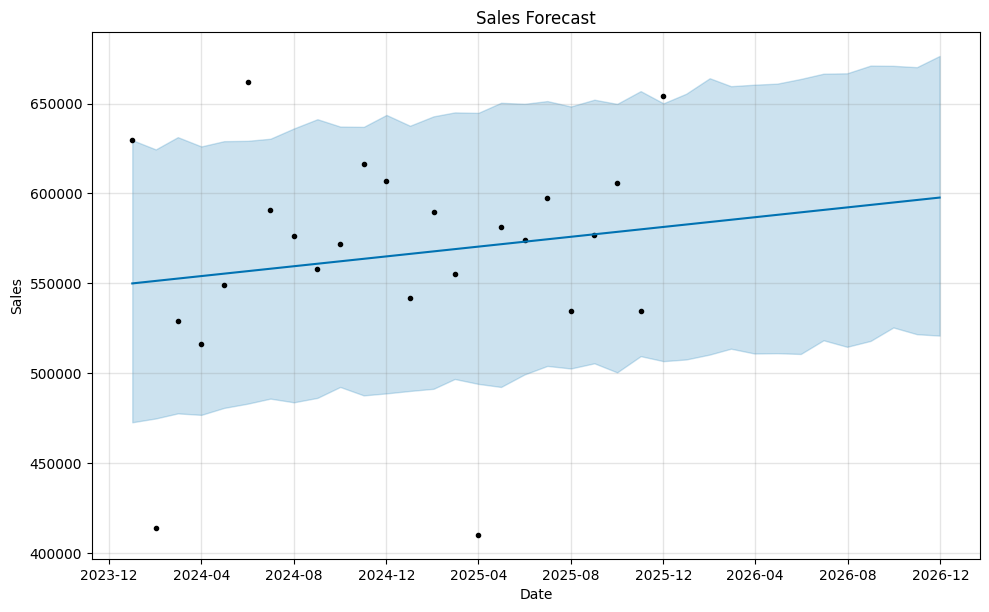

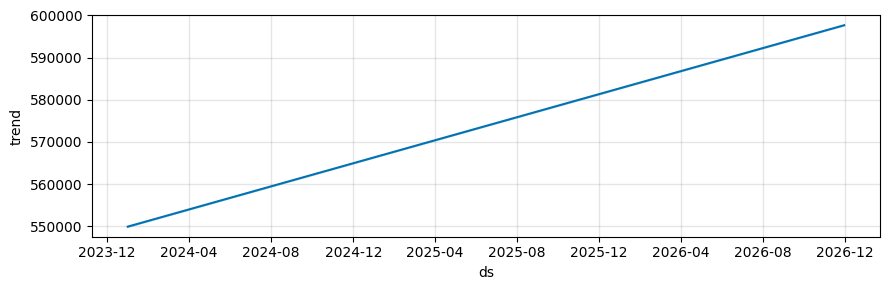

Sales trend prediction generated successfully!


In [460]:
!pip install prophet

import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Ensure monthly_sales DataFrame is in the correct format for Prophet
# Assuming monthly_sales is already defined and contains 'Period' and 'Sales'
# from previous steps (e.g., from cell WHS8vy5xH9-_)

# Create a copy to avoid SettingWithCopyWarning
prophet_df = monthly_sales.copy()

# Convert 'Period' to datetime and rename columns as required by Prophet
prophet_df['ds'] = pd.to_datetime(prophet_df['Period'])
prophet_df['y'] = prophet_df['Sales']

# Select only the required columns
prophet_df = prophet_df[['ds', 'y']]

# Initialize and fit the Prophet model
model = Prophet()
model.fit(prophet_df)

# Create a DataFrame for future predictions (e.g., next 12 months)
future = model.make_future_dataframe(periods=12, freq='M')

# Make predictions
forecast = model.predict(future)

# Plot the forecast
plt.figure(figsize=(12, 6))
model.plot(forecast, xlabel='Date', ylabel='Sales')
plt.title('Sales Forecast')
plt.show()

# Plot the forecast components
model.plot_components(forecast)
plt.show()

print("Sales trend prediction generated successfully!")

In [461]:
# Final dataset for Power BI Dashboard

final_path = "/content/drive/MyDrive/data science/sales_feature_engineered.csv"

print("Final Dataset Ready:")
print("File:", final_path)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Final Dataset Ready:
File: /content/drive/MyDrive/data science/sales_feature_engineered.csv
Rows: 12015
Columns: 27


In [462]:
from google.colab import files

files.download("/content/drive/MyDrive/data science/sales_feature_engineered.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>